# Flight Price Prediction — Model Building & Evaluation

Trains 7 regressors, runs cross-validation, plots residuals, and tunes the best performer with GridSearchCV.

In [1]:
# Make paths work in Google Colab, local Jupyter, and GitHub clones
import os, sys
from pathlib import Path

current_dir = Path.cwd()

# Case 1: notebook opened from the notebooks folder
if current_dir.name == 'notebooks':
    os.chdir(current_dir.parent)

# Case 2: notebook opened from /content in Colab after unzipping
elif not Path('data').exists():
    possible_roots = list(current_dir.glob('Flight-Price-Prediction-Study-Project')) + list(current_dir.glob('Flight-Price-Prediction'))
    if possible_roots:
        os.chdir(possible_roots[0])

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print('Working directory:', project_root)
print('Data folder exists:', Path('data').exists())






Working directory: /content/Flight-Price-Prediction/Flight-Price-Prediction/Flight-Price-Prediction/Flight-Price-Prediction
Data folder exists: True


## 1. Imports & Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from utils import (
    evaluate_model, plot_residuals, plot_pred_vs_actual,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline




In [3]:
df = pd.read_csv('data/flights_cleaned.csv')

# For study and Colab speed, use 20,000 rows.
# Change SAMPLE_SIZE to None if you want to train on the full cleaned dataset.
SAMPLE_SIZE = 5_000
if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print('Shape:', df.shape)
df.head()




Shape: (5000, 31)


,stops,duration,days_left,price,log_duration,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,1,7.08,38,5352,2.089392,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,1
1,2,14.08,22,9433,2.713369,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,1
2,1,4.67,6,14301,1.735189,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
3,2,14.00,32,8719,2.708050,0,0,0,0,1,...,0,0,0,1,1,0,0,0,0,1
4,1,16.92,45,56273,2.885917,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


## 2. Train / Test Split & Scaling

In [4]:
X = df.drop(columns=['price'])
y = df['price']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)




Features: 30
Target stats:
count      5000.00
mean      21024.23
std       22624.64
min        1105.00
25%        4844.75
50%        7542.50
75%       43186.75
max      100671.00
Name: price, dtype: float64
Train: (4000, 30) Test: (1000, 30)


## 3. Train 7 Regressors

In [5]:
results = []
models = {}





  Linear Regression
  MAE   : 4790.5471
  RMSE  : 6832.9006
  R2    : 0.9112
  MAPE  : 0.4789


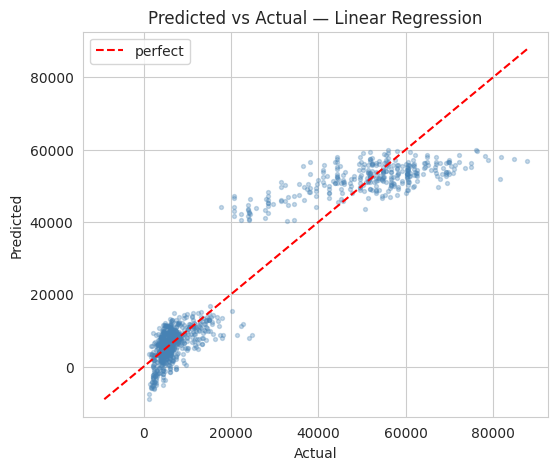

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_pred_vs_actual(y_test, y_pred, 'Linear Regression'); plt.show()





  Ridge
  MAE   : 4789.7797
  RMSE  : 6833.0967
  R2    : 0.9112
  MAPE  : 0.4785


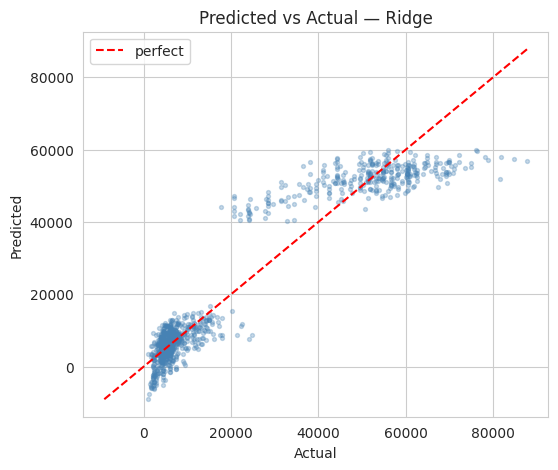

In [7]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_pred_vs_actual(y_test, y_pred, 'Ridge'); plt.show()





  Lasso
  MAE   : 4790.4208
  RMSE  : 6832.9409
  R2    : 0.9112
  MAPE  : 0.4789


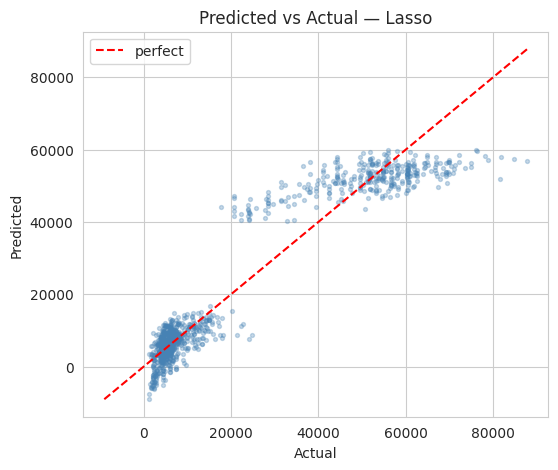

In [8]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_pred_vs_actual(y_test, y_pred, 'Lasso'); plt.show()





  Decision Tree
  MAE   : 3053.8456
  RMSE  : 5266.4458
  R2    : 0.9473
  MAPE  : 0.1884


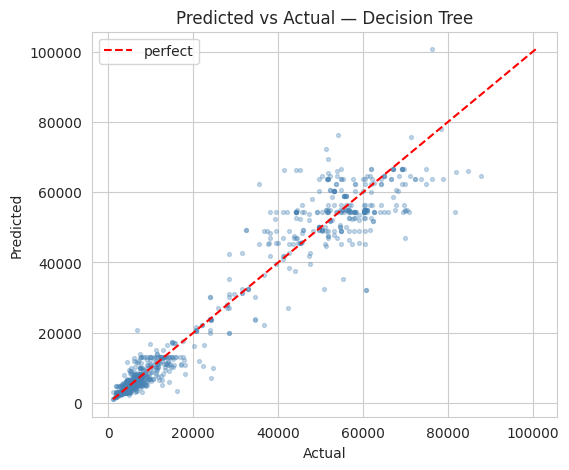

In [9]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_pred_vs_actual(y_test, y_pred, 'Decision Tree'); plt.show()





  Random Forest
  MAE   : 2582.8107
  RMSE  : 4336.7575
  R2    : 0.9642
  MAPE  : 0.1620


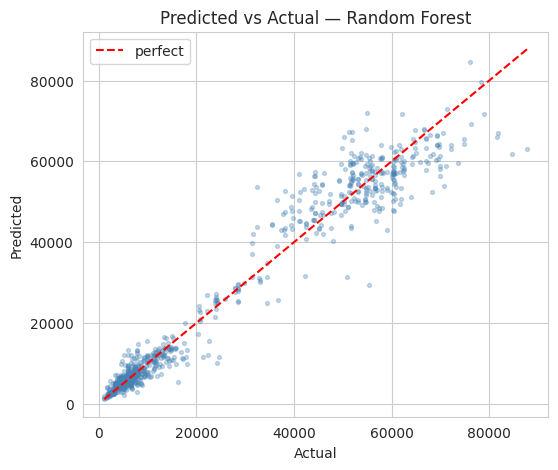

In [10]:
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_pred_vs_actual(y_test, y_pred, 'Random Forest'); plt.show()




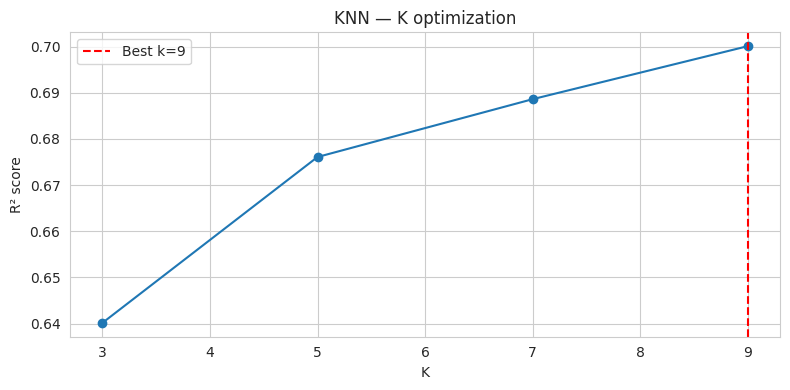


  KNN (k=9)
  MAE   : 9017.4413
  RMSE  : 12560.6611
  R2    : 0.7001
  MAPE  : 0.9147


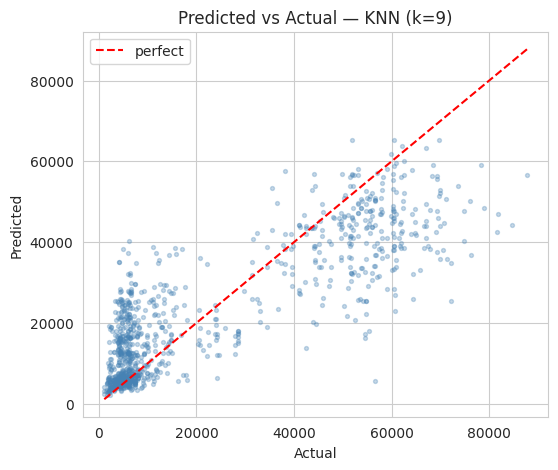

In [11]:
k_range = [3, 5, 7, 9]
from sklearn.metrics import r2_score
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4)); plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_pred_vs_actual(y_test, y_pred, knn_label); plt.show()





  Gradient Boosting
  MAE   : 3187.3218
  RMSE  : 5092.6012
  R2    : 0.9507
  MAPE  : 0.2222


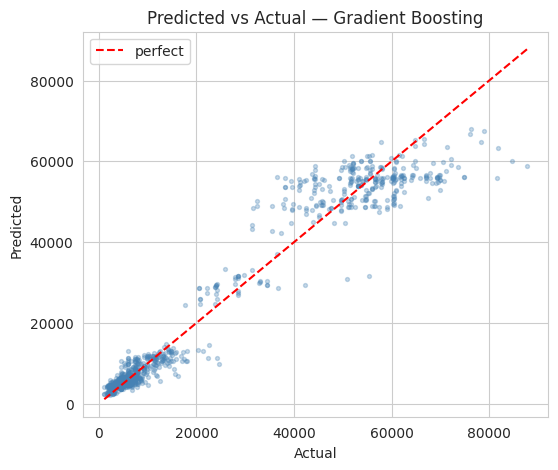

In [12]:
gb = GradientBoostingRegressor(n_estimators=50, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_pred_vs_actual(y_test, y_pred, 'Gradient Boosting'); plt.show()




## 4. Feature Importance — Tree Models

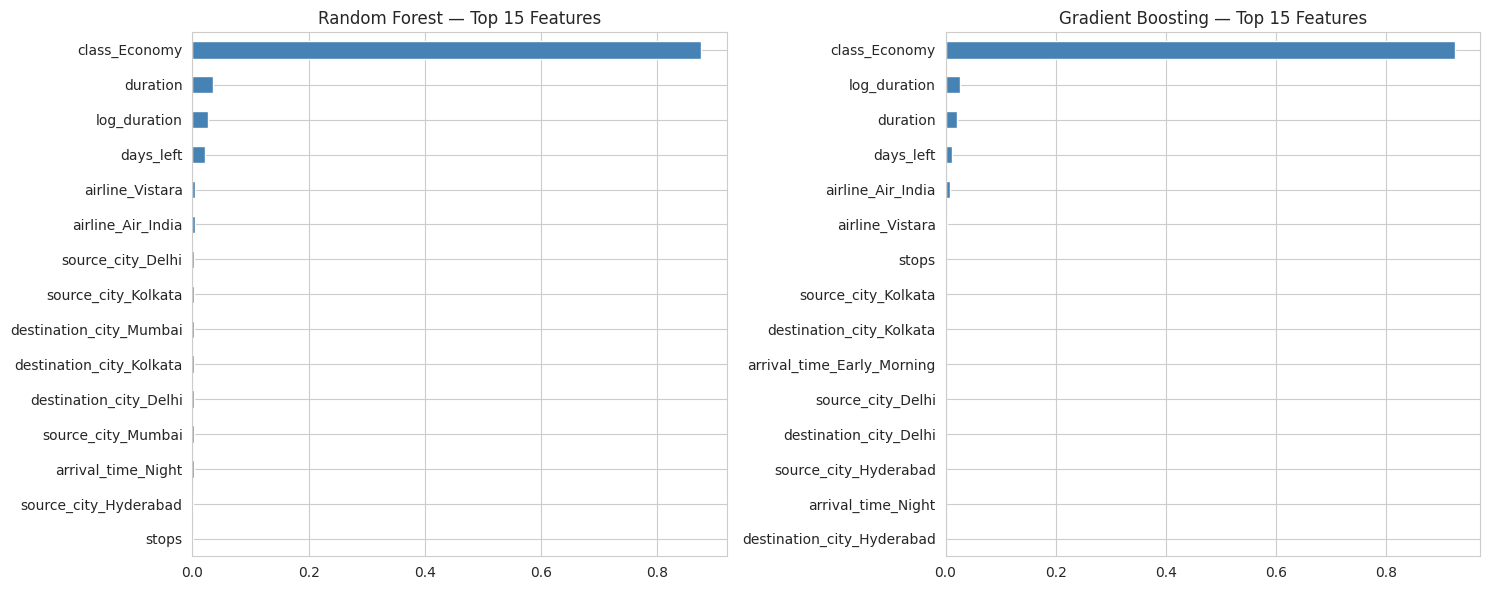

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout(); plt.show()




## 5. Model Comparison

In [14]:
comparison = compare_models(results)
comparison




,Model,MAE,RMSE,R2,MAPE
0,Random Forest,2582.810706,4336.757482,0.964248,0.162049
1,Gradient Boosting,3187.321814,5092.601153,0.950699,0.222162
2,Decision Tree,3053.845569,5266.445774,0.947276,0.188429
3,Linear Regression,4790.547124,6832.900609,0.911247,0.478942
4,Lasso,4790.420774,6832.940940,0.911246,0.478887
5,Ridge,4789.779744,6833.096704,0.911242,0.478542
6,KNN (k=9),9017.441333,12560.661069,0.700085,0.914651


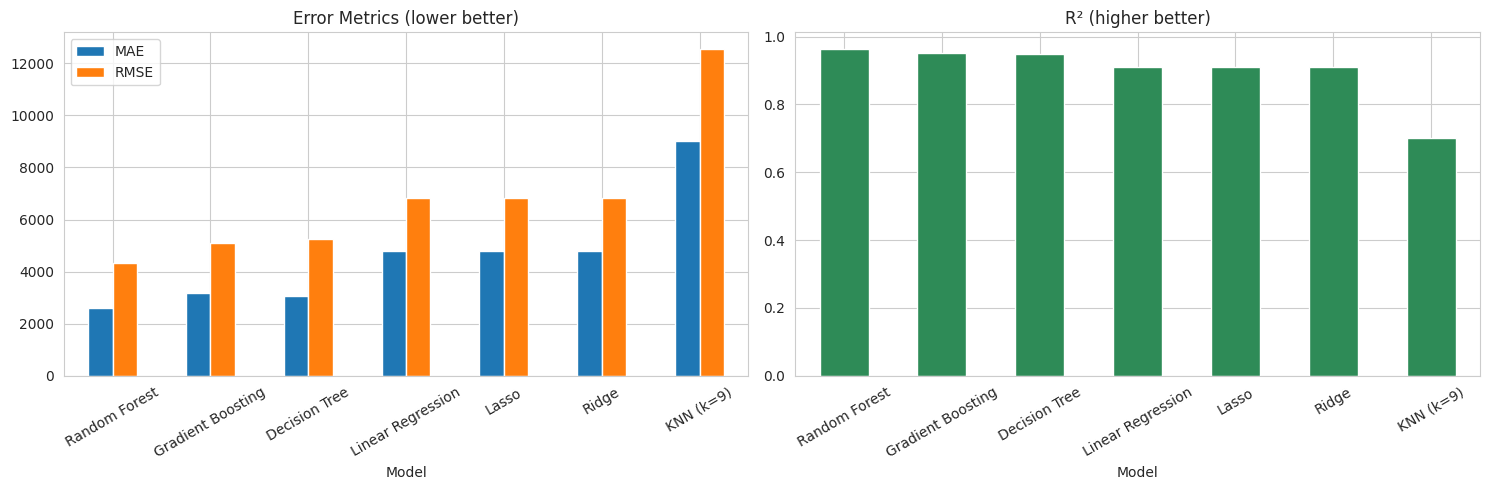

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)
comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()




## 6. 5-Fold Cross-Validation

In [16]:
cv_idx = np.random.RandomState(42).choice(len(X), size=min(len(X), 1000), replace=False)
X_cv, y_cv = X.iloc[cv_idx], y.iloc[cv_idx]
X_cv_scaled = scaler.fit_transform(X_cv)
print('CV sample size:', len(X_cv))




CV sample size: 1000


In [17]:
cv_scores = {}
for name, (kind, model) in models.items():
    if kind == 'scaled':
        scores = cross_val_score(model, X_cv_scaled, y_cv, cv=5, scoring='r2', n_jobs=1)
    else:
        scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='r2', n_jobs=1)
    cv_scores[name] = scores
    print(f'{name:25s} mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})')




Linear Regression         mean R² = 0.9101 (+/- 0.0094)
Ridge                     mean R² = 0.9101 (+/- 0.0094)
Lasso                     mean R² = 0.9101 (+/- 0.0094)
Decision Tree             mean R² = 0.9029 (+/- 0.0155)


Random Forest             mean R² = 0.9438 (+/- 0.0077)
KNN (k=9)                 mean R² = 0.5985 (+/- 0.0266)


Gradient Boosting         mean R² = 0.9465 (+/- 0.0063)


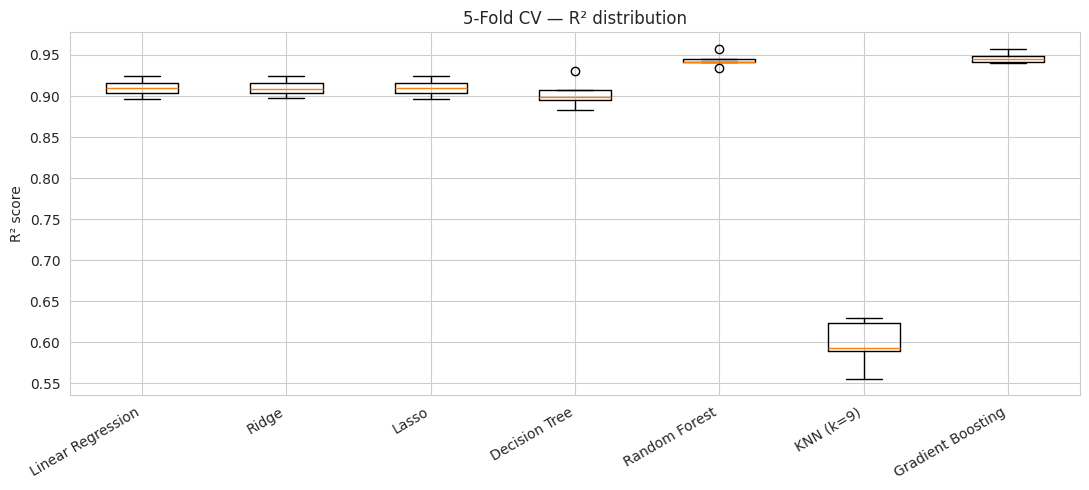

In [18]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('R² score')
plt.title('5-Fold CV — R² distribution'); plt.tight_layout(); plt.show()




## 7. Residuals — Best Model

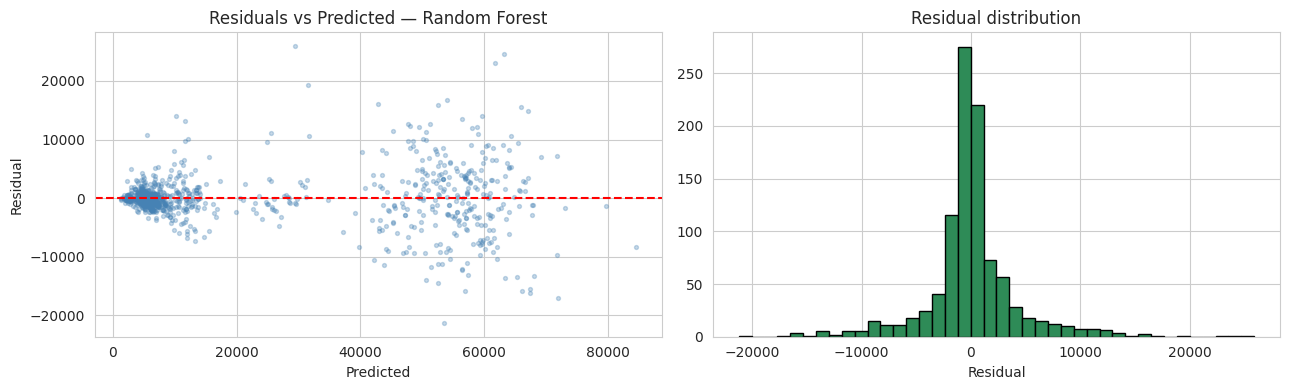

In [19]:
best_model_name = comparison.iloc[0]['Model']
kind, best_pre = models[best_model_name]
Xt = X_test_scaled if kind == 'scaled' else X_test
y_pred_best = best_pre.predict(Xt)
plot_residuals(y_test, y_pred_best, best_model_name); plt.show()




## 8. Hyperparameter Tuning — Best Performer

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV R²: 0.9529

  Random Forest (Tuned)
  MAE   : 2540.0813
  RMSE  : 4272.4629
  R2    : 0.9653
  MAPE  : 0.1615


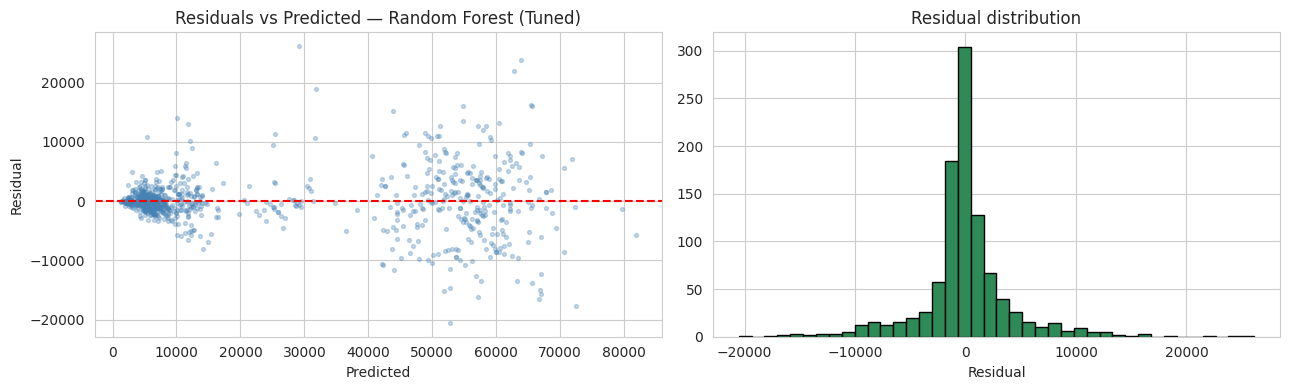

In [20]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [None],
    'min_samples_leaf': [1, 2],
}
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=1)
grid = GridSearchCV(rf_tuned, param_grid, cv=3, scoring='r2', n_jobs=1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Random Forest (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_residuals(y_test, y_pred, 'Random Forest (Tuned)'); plt.show()




## 9. Tuned Model — Feature Importance

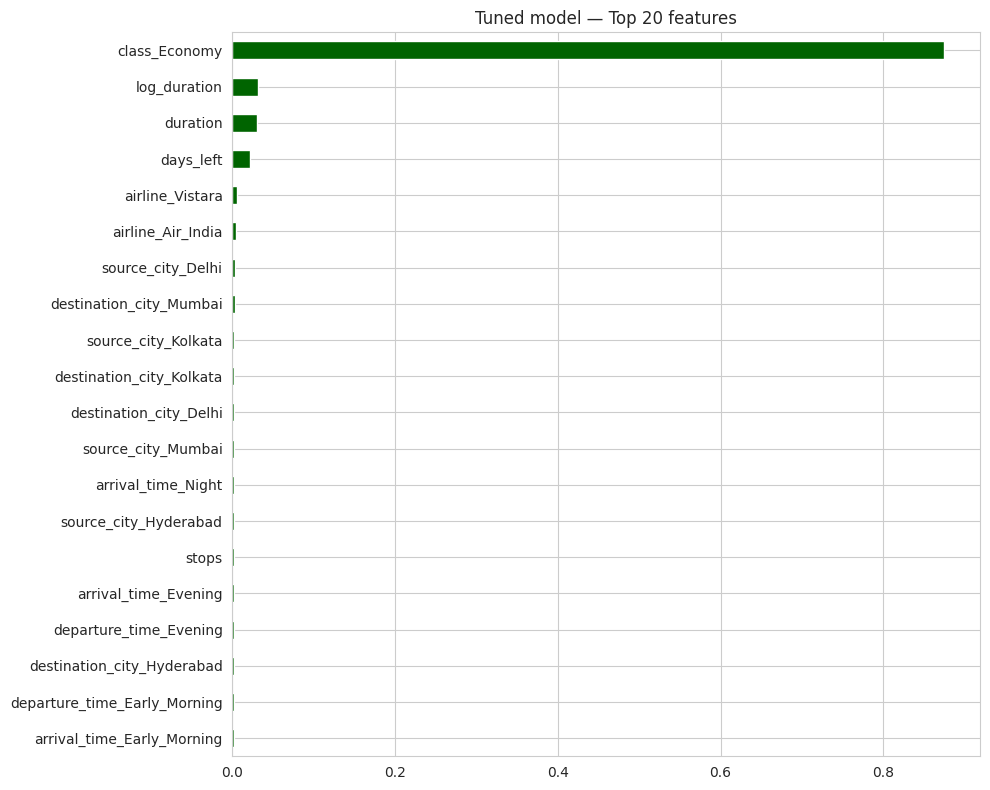

In [21]:
if hasattr(best, 'feature_importances_'):
    importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
    importances = pd.Series(np.abs(best.coef_), index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 |coefficients|'); plt.tight_layout(); plt.show()




## 10. Sample Prediction

In [22]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)
out = pd.DataFrame({'Predicted': preds.round(2), 'Actual': y_test.iloc[:5].values.round(2)})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out




,Predicted,Actual,AbsError
0,5709.25,4357,1352.25
1,4393.29,4500,106.71
2,6490.28,7572,1081.72
3,6013.50,5882,131.50
4,67847.86,66671,1176.86


## 11. Final Summary

In [23]:
final = compare_models(results)
final




,Model,MAE,RMSE,R2,MAPE
0,Random Forest (Tuned),2540.081292,4272.462924,0.965300,0.161533
1,Random Forest,2582.810706,4336.757482,0.964248,0.162049
2,Gradient Boosting,3187.321814,5092.601153,0.950699,0.222162
3,Decision Tree,3053.845569,5266.445774,0.947276,0.188429
4,Linear Regression,4790.547124,6832.900609,0.911247,0.478942
5,Lasso,4790.420774,6832.940940,0.911246,0.478887
6,Ridge,4789.779744,6833.096704,0.911242,0.478542
7,KNN (k=9),9017.441333,12560.661069,0.700085,0.914651


### Key Takeaways

- Flight Price Prediction: regression on `price`.
- 7 regressors + 1 tuned variant evaluated on MAE / RMSE / R² / MAPE.
- Tree-based models highlight the most predictive features.
- Predicted-vs-actual scatter plots reveal where models systematically over/underestimate.

### Next Steps

- Try gradient boosters (XGBoost, LightGBM) for further gains.
- Apply log-transform on skewed targets and re-fit.
- Add domain-specific feature engineering.